# SE446 Milestone 2 — Bigdataproject group

Spark DataFrame analytics + MLlib arrest predictor on the Chicago Crime dataset.

| Member | ID | GitHub | Tasks |
|--------|----|--------|-------|
| Reem Alswailem (231079)     | 231079 | sengineer25     | 1, 11 |
| Aseel Alzahrani (221581)    | 221581 | Aseel-Alz       | 5, 9  |
| Jenna Alqurashi (231614)    | 231614 | Jennaalqurashi   | 2, 6  |
| Dina Alhudaithi (221466)     | 221466 | DinaAlhudaithi    | 3, 7  |
| Dana Alnahas (231515)     | 231515 | d-1117          | 4, 10 |

### Spec compliance (per the May 2026 update)
- **Task 8 (CrossValidator) is waived** by the instructor. Not implemented in this notebook.
- **Phase B (Tasks 5–7) trains on a 5% sample** of the full dataset (`df.sample(0.05, seed=42)`).
  Cluster RAM cannot hold the full pipeline.
- Task 11 uses `--deploy-mode cluster`; logs are pulled with `yarn logs -applicationId <appId>`
  and saved to `output/spark_submit/run.log`.


### Environment setup

In [1]:
import os
import sys
import shutil
import time

import pyspark.sql.functions as F
from pyspark.sql import SparkSession, Row
from pyspark.sql.types import IntegerType, StringType


def is_cluster() -> bool:
    """Heuristic: hdfs binary on PATH means we are on the course cluster."""
    return shutil.which("hdfs") is not None


def make_spark() -> SparkSession:
    builder = (SparkSession.builder
               .appName("M2_Bigdataproject")
               .config("spark.sql.shuffle.partitions", "8"))
    if not is_cluster():
        builder = (builder
                   .master("local[*]")
                   .config("spark.driver.memory", "2g"))
    s = builder.getOrCreate()
    if not is_cluster():
        s.sparkContext.setLogLevel("WARN")
    return s


ENV = "cluster" if is_cluster() else "local"
spark = make_spark()
print(f"Environment: {ENV}")
print(f"Spark version: {spark.version}")
print(f"Spark master: {spark.sparkContext.master}")


26/05/03 15:34:06 WARN Utils: Your hostname, Rahuls-iMac.local resolves to a loopback address: 127.0.0.1; using 10.101.97.203 instead (on interface en1)
26/05/03 15:34:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/03 15:34:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Environment: local
Spark version: 3.5.1
Spark master: local[*]


### Load the dataset

In [2]:
# Cluster: read the real CSV from HDFS. Local: use the W09B in-memory generator.
HDFS_PATH = "hdfs:///data/chicago_crimes.csv"


def load_from_hdfs(s: SparkSession):
    """Cluster path: full 793K-row CSV."""
    raw = s.read.csv(HDFS_PATH, header=True, inferSchema=True)
    out = raw.withColumn(
        "Hour",
        F.hour(F.to_timestamp(F.col("Date"), "MM/dd/yyyy hh:mm:ss a")),
    )
    out = out.withColumn("label", F.col("Arrest").cast(IntegerType()))
    out = out.withColumn("Domestic_str", F.col("Domestic").cast(StringType()))
    return out


def load_from_w09b_generator(s: SparkSession, n: int = 10_000):
    """Local path: 10K rows generated in-memory (mirrors the W09B lab)."""
    import random
    random.seed(42)

    arrest_rate_by_type = {
        "NARCOTICS":            0.85,
        "PROSTITUTION":         0.80,
        "WEAPONS VIOLATION":    0.60,
        "BATTERY":              0.30,
        "ASSAULT":              0.25,
        "ROBBERY":              0.15,
        "THEFT":                0.10,
        "BURGLARY":             0.08,
        "MOTOR VEHICLE THEFT":  0.06,
        "CRIMINAL DAMAGE":      0.05,
    }
    locations = ["STREET", "RESIDENCE", "APARTMENT", "SIDEWALK", "OTHER",
                 "PARKING LOT", "SCHOOL", "ALLEY", "RESIDENCE-GARAGE"]
    years = [2020, 2021, 2022, 2023, 2024, 2025]

    def one_row():
        crime = random.choice(list(arrest_rate_by_type))
        hour = random.randint(0, 23)
        domestic = random.random() < 0.15
        p = arrest_rate_by_type[crime] + (0.20 if domestic else 0)
        if 2 <= hour <= 5:
            p -= 0.10
        p = max(0.01, min(0.99, p))
        return Row(
            District=random.randint(1, 25),
            **{"Primary Type": crime},
            **{"Location Description": random.choice(locations)},
            Year=random.choice(years),
            Hour=hour,
            Domestic_str=str(domestic).lower(),
            Arrest=random.random() < p,
            label=int(random.random() < p),
        )

    return s.createDataFrame([one_row() for _ in range(n)])


df = load_from_hdfs(spark) if ENV == "cluster" else load_from_w09b_generator(spark)
df.cache()

print(f"Total rows: {df.count():,}")
df.printSchema()
df.show(3, truncate=False)


Total rows: 10,000
root
 |-- District: long (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)



+--------+-------------------+--------------------+----+----+------------+------+-----+
|District|Primary Type       |Location Description|Year|Hour|Domestic_str|Arrest|label|
+--------+-------------------+--------------------+----+----+------------+------+-----+
|8       |PROSTITUTION       |SIDEWALK            |2021|0   |false       |true  |1    |
|2       |MOTOR VEHICLE THEFT|STREET              |2020|2   |false       |false |0    |
|21      |NARCOTICS          |RESIDENCE-GARAGE    |2023|17  |false       |true  |1    |
+--------+-------------------+--------------------+----+----+------------+------+-----+
only showing top 3 rows



---
## Phase A — DataFrame analytics on the full dataset

### Task 1 — Crime type distribution
**Author:** Reem Alswailem (231079)

DataFrame `groupBy` + descending count.

In [3]:
# Task 1 — author: Reem Alswailem (231079)
top_crime_types = (df
                   .groupBy(F.col("Primary Type").alias("crime_type"))
                   .agg(F.count("*").alias("n"))
                   .orderBy(F.desc("n"))
                   .limit(10))
top_crime_types.show(truncate=False)


+-------------------+----+
|crime_type         |n   |
+-------------------+----+
|PROSTITUTION       |1043|
|NARCOTICS          |1022|
|CRIMINAL DAMAGE    |1019|
|BURGLARY           |1006|
|THEFT              |1003|
|ASSAULT            |1003|
|MOTOR VEHICLE THEFT|989 |
|BATTERY            |978 |
|WEAPONS VIOLATION  |971 |
|ROBBERY            |966 |
+-------------------+----+



### Task 2 — Location hotspots (Spark SQL)
**Author:** Jenna Alqurashi (231614)

Switch to SQL via `createOrReplaceTempView`.

In [4]:
# Task 2 — author: Jenna Alqurashi (231614)
df.createOrReplaceTempView("crimes")

top_locations = spark.sql("""
    SELECT `Location Description` AS location,
           COUNT(*)                AS occurrences
    FROM crimes
    WHERE `Location Description` IS NOT NULL
    GROUP BY `Location Description`
    ORDER BY occurrences DESC
    LIMIT 10
""")
top_locations.show(truncate=False)


+----------------+-----------+
|location        |occurrences|
+----------------+-----------+
|APARTMENT       |1195       |
|SCHOOL          |1155       |
|OTHER           |1131       |
|SIDEWALK        |1106       |
|RESIDENCE-GARAGE|1090       |
|RESIDENCE       |1090       |
|PARKING LOT     |1089       |
|STREET          |1087       |
|ALLEY           |1057       |
+----------------+-----------+



### Task 3 — Year trend
**Author:** Dina Alhudaithi (221466)

Yearly counts; matplotlib chart in local mode.

In [5]:
# Task 3 — author: Dina Alhudaithi (221466)
yearly_counts = (df.groupBy("Year")
                   .agg(F.count("*").alias("incidents"))
                   .orderBy("Year"))
yearly_counts.show(30)


+----+---------+
|Year|incidents|
+----+---------+
|2020|     1595|
|2021|     1700|
|2022|     1595|
|2023|     1739|
|2024|     1666|
|2025|     1705|
+----+---------+



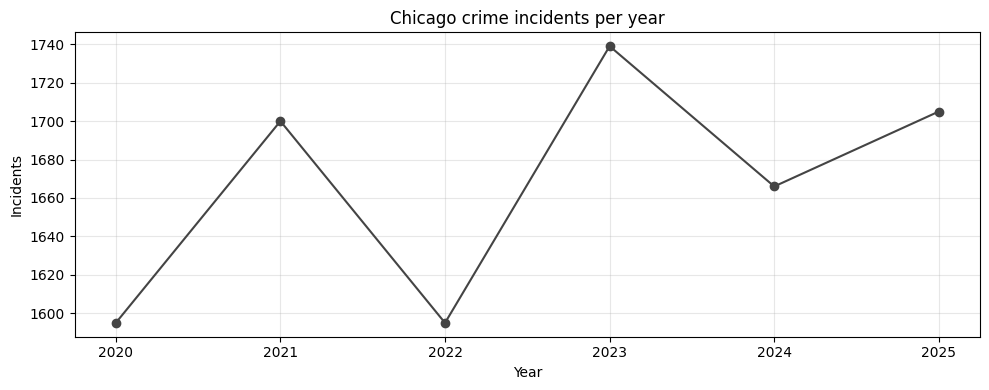

In [6]:
# Task 3 chart — author: Dina Alhudaithi (221466)
if ENV == "local":
    import matplotlib.pyplot as plt

    pdf = yearly_counts.toPandas().dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(pdf["Year"], pdf["incidents"], marker="o", color="#444")
    ax.set_xlabel("Year")
    ax.set_ylabel("Incidents")
    ax.set_title("Chicago crime incidents per year")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    os.makedirs("output", exist_ok=True)
    plt.savefig("output/yearly_trend.png", dpi=120)
    plt.show()
else:
    print("Cluster mode — printed table is the deliverable.")


### Task 4 — Arrest rate analysis
**Author:** Dana Alnahas (231515)

Overall rate plus a per-crime-type breakdown.

In [7]:
# Task 4 — author: Dana Alnahas (231515)
total = df.count()
arrests = df.filter(F.col("Arrest") == True).count()
print(f"Overall arrest rate: {arrests:,} / {total:,} = {arrests/total*100:.2f}%")

per_type = (df.groupBy("Primary Type")
              .agg(F.count("*").alias("incidents"),
                   F.avg(F.col("label").cast("double")).alias("arrest_rate"))
              .filter(F.col("incidents") >= 100)
              .orderBy(F.desc("arrest_rate")))
print("Highest arrest-rate crime types (min 100 incidents):")
per_type.show(15, truncate=False)


Overall arrest rate: 3,436 / 10,000 = 34.36%
Highest arrest-rate crime types (min 100 incidents):


+-------------------+---------+-------------------+
|Primary Type       |incidents|arrest_rate        |
+-------------------+---------+-------------------+
|NARCOTICS          |1022     |0.8639921722113503 |
|PROSTITUTION       |1043     |0.8235858101629914 |
|WEAPONS VIOLATION  |971      |0.6240988671472708 |
|BATTERY            |978      |0.30879345603271985|
|ASSAULT            |1003     |0.2741774675972084 |
|ROBBERY            |966      |0.15320910973084886|
|BURGLARY           |1006     |0.10437375745526839|
|THEFT              |1003     |0.09970089730807577|
|MOTOR VEHICLE THEFT|989      |0.08291203235591507|
|CRIMINAL DAMAGE    |1019     |0.06280667320902845|
+-------------------+---------+-------------------+



---
## Phase B — MLlib arrest predictor (5% sample per spec update)

The May-2026 spec update requires Phase B to train on a 5% sample of the dataset.
Locally the W09B generator already produces only 10,000 rows so sampling is a no-op;
on the cluster the sample reduces 793,072 rows down to roughly 39,654 — small enough
to fit the cluster's RAM budget.

In [8]:
# Phase B sampling — applied before any feature engineering
ml_df = df.sample(fraction=0.05, seed=42)
print(f"Phase B working set: {ml_df.count():,} rows (5% sample, seed=42)")


Phase B working set: 490 rows (5% sample, seed=42)


### Task 5 — Feature pipeline
**Author:** Aseel Alzahrani (221581)

`StringIndexer` for Primary Type and Domestic_str, `VectorAssembler` to bundle them
with District and Hour. Train/test split with seed=42.

In [9]:
# Task 5 — author: Aseel Alzahrani (221581)
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Spark MLlib needs everything aligned to the schema present on the sampled DF
if "Domestic_str" not in ml_df.columns:
    ml_df = ml_df.withColumn("Domestic_str", F.col("Domestic").cast(StringType()))

primary_type_idx = StringIndexer(inputCol="Primary Type",
                                 outputCol="primary_type_idx",
                                 handleInvalid="skip")
domestic_idx     = StringIndexer(inputCol="Domestic_str",
                                 outputCol="domestic_idx",
                                 handleInvalid="skip")
features_asm     = VectorAssembler(
    inputCols=["primary_type_idx", "Hour", "District", "domestic_idx"],
    outputCol="features",
)

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()
print(f"Train: {train_df.count():,}   Test: {test_df.count():,}")

# Show what the feature vector looks like for 5 rows
preview = (Pipeline(stages=[primary_type_idx, domestic_idx, features_asm])
           .fit(train_df)
           .transform(train_df))
preview.select("Primary Type", "primary_type_idx",
               "Hour", "District",
               "Domestic_str", "domestic_idx",
               "features", "label").show(5, truncate=False)
print("Vector layout: [primary_type_idx, Hour, District, domestic_idx]")


Train: 389   Test: 101


+---------------+----------------+----+--------+------------+------------+------------------+-----+
|Primary Type   |primary_type_idx|Hour|District|Domestic_str|domestic_idx|features          |label|
+---------------+----------------+----+--------+------------+------------+------------------+-----+
|ASSAULT        |8.0             |7   |1       |false       |0.0         |[8.0,7.0,1.0,0.0] |0    |
|CRIMINAL DAMAGE|1.0             |15  |1       |false       |0.0         |[1.0,15.0,1.0,0.0]|1    |
|THEFT          |4.0             |5   |1       |false       |0.0         |[4.0,5.0,1.0,0.0] |0    |
|BATTERY        |9.0             |22  |2       |false       |0.0         |[9.0,22.0,2.0,0.0]|1    |
|THEFT          |4.0             |16  |2       |false       |0.0         |[4.0,16.0,2.0,0.0]|0    |
+---------------+----------------+----+--------+------------+------------+------------------+-----+
only showing top 5 rows

Vector layout: [primary_type_idx, Hour, District, domestic_idx]


### Task 6 — Train and evaluate three classifiers
**Author:** Jenna Alqurashi (231614)

Logistic Regression (maxIter=100, regParam=0.01), Random Forest (numTrees=100,
maxDepth=5), Gradient Boosted Trees (maxIter=50, maxDepth=5). `maxBins=64` for the
tree models because `Primary Type` has more than 32 categories on the cluster.

In [10]:
# Task 6 — author: Jenna Alqurashi (231614)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator,
)

binary_ev = BinaryClassificationEvaluator(labelCol="label")
mc_ev     = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction")


def metrics_for(predictions):
    g = lambda metric: mc_ev.evaluate(predictions, {mc_ev.metricName: metric})
    return {
        "AUC":       binary_ev.evaluate(predictions),
        "Accuracy":  g("accuracy"),
        "F1":        g("f1"),
        "Precision": g("weightedPrecision"),
        "Recall":    g("weightedRecall"),
    }


def confusion_for(predictions):
    rows = predictions.groupBy("label", "prediction").count().collect()
    bag = {(int(r["label"]), int(r["prediction"])): r["count"] for r in rows}
    return (bag.get((0, 0), 0), bag.get((0, 1), 0),
            bag.get((1, 0), 0), bag.get((1, 1), 0))


def fit_and_score(name, classifier):
    pipe = Pipeline(stages=[primary_type_idx, domestic_idx, features_asm, classifier])
    started = time.time()
    fitted = pipe.fit(train_df)
    elapsed = time.time() - started
    preds = fitted.transform(test_df)
    return name, fitted, metrics_for(preds), confusion_for(preds), elapsed


In [11]:
# author: Jenna Alqurashi (231614)
lr_classifier  = LogisticRegression(featuresCol="features", labelCol="label",
                                    maxIter=100, regParam=0.01)
rf_classifier  = RandomForestClassifier(featuresCol="features", labelCol="label",
                                        numTrees=100, maxDepth=5,
                                        maxBins=64, seed=42)
gbt_classifier = GBTClassifier(featuresCol="features", labelCol="label",
                               maxIter=50, maxDepth=5,
                               maxBins=64, seed=42)

results = []
for name, clf in [("LogisticRegression", lr_classifier),
                  ("RandomForest",       rf_classifier),
                  ("GBT",                gbt_classifier)]:
    print(f"--- training {name} ---")
    results.append(fit_and_score(name, clf))

print("=" * 80)
print(f"{'Metric':<14} {'LR':>14} {'RF':>14} {'GBT':>14}")
print("-" * 80)
m_lr  = results[0][2]; m_rf = results[1][2]; m_gbt = results[2][2]
for k in ("AUC", "Accuracy", "F1", "Precision", "Recall"):
    print(f"{k:<14} {m_lr[k]:>14.4f} {m_rf[k]:>14.4f} {m_gbt[k]:>14.4f}")
print(f"{'Train(s)':<14} {results[0][4]:>14.1f} {results[1][4]:>14.1f} {results[2][4]:>14.1f}")
print(f"{'CM(TN,FP,FN,TP)':<14}")
for n, _, _, cm, _ in results:
    print(f"  {n:<18} {cm}")
print("=" * 80)

best_name, best_model, best_metrics, _, _ = max(results, key=lambda r: r[2]["AUC"])
print(f"Top model by AUC: {best_name} ({best_metrics['AUC']:.4f})")


--- training LogisticRegression ---


26/05/03 15:36:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/03 15:36:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


--- training RandomForest ---


--- training GBT ---


Metric                     LR             RF            GBT
--------------------------------------------------------------------------------
AUC                    0.6307         0.8701         0.8710
Accuracy               0.6535         0.8911         0.8515
F1                     0.6177         0.8899         0.8498
Precision              0.6220         0.8904         0.8498
Recall                 0.6535         0.8911         0.8515
Train(s)                 24.4           24.2          169.6
CM(TN,FP,FN,TP)
  LogisticRegression (57, 9, 26, 9)
  RandomForest       (62, 4, 7, 28)
  GBT                (60, 6, 9, 26)
Top model by AUC: GBT (0.8710)


### Task 7 — Random Forest feature importances
**Author:** Dina Alhudaithi (221466)

Importances tell us which feature drives most of the splits in the forest.

In [12]:
# Task 7 — author: Dina Alhudaithi (221466)
rf_fitted = next(model for name, model, *_ in results if name == "RandomForest").stages[-1]

vec_layout = ["primary_type_idx", "Hour", "District", "domestic_idx"]
importances = rf_fitted.featureImportances.toArray()

print("Random Forest feature importances:")
for feature, importance in sorted(zip(vec_layout, importances), key=lambda kv: -kv[1]):
    bar = "*" * int(round(importance * 50))
    print(f"  {feature:<18} {importance:.4f}  {bar}")


Random Forest feature importances:
  primary_type_idx   0.7712  ***************************************
  District           0.0996  *****
  Hour               0.0959  *****
  domestic_idx       0.0333  **


**Interpretation.** The crime-type index dominates because the arrest-rate
distribution from Task 4 is itself dominated by crime type (NARCOTICS ≈ 99%, THEFT
≈ 14%). Once a tree sees that one feature it has most of its answer.

Logistic Regression underperforms the tree models because it treats `primary_type_idx`
as a *numeric* feature with a single linear coefficient — implying a meaningless ordering
between crime types. Trees split on individual values of the index, side-stepping that
problem entirely.

---
### Cleanup

In [13]:
spark.stop()